# Home Work 1
## Created by: Frendl Krisztián & Kozicz Gergő


### 1. Setup and Data Loading


In [1]:
import pandas as pd
import matplotlib.pyplot as plt


df = pd.read_excel('classroom_data.xlsx')
print("Data loaded successfully!")
df.head()

Data loaded successfully!


,time,outside_temp,occupants,hvac
0,07:00:00,7,0,1
1,08:00:00,8,5,1
2,09:00:00,9,25,1
3,10:00:00,11,30,0
4,11:00:00,13,30,0


## 2-5. Simulation Logic
Implementation Task 3-5: For each hour calculate heat exchange, HVAC effect and occupant heat. Update indoor temperature and store the simulated temperature.

Using the provided formula:
$$T(t+\Delta t) = T(t) + \Delta t \cdot [ k(T_{outside} - T) + \alpha \cdot HVAC + \beta \cdot occupancy ]$$

With parameters:
*   $k = 0.10$
*   $\alpha = 1.5$
*   $\beta = 0.02$
*   Initial $T_0 = 20^\circ C$
*   $\Delta t = 1$ (hour)

In [2]:
def run_simulation(data, hvac_modifier=1.0, occupant_mode='normal', t_out_offset=0.0):
    k = 0.10      
    alpha = 1.5   
    beta = 0.02   
    delta_t = 1   
    
    T0 = 20.0     
    T_indoor = [T0]
    
    
    for i in range(len(data)):
        T_in = T_indoor[-1]
        T_out = data.loc[i, 'outside_temp'] + t_out_offset
        hvac = data.loc[i, 'hvac'] * hvac_modifier
        occ = data.loc[i, 'occupants']
        
        # Extracting the teaching hour
        hour_str = str(data.loc[i, 'time'])
        hour = int(hour_str.split(':')[0])
        
        # Scenario C: use 40 occupants during teaching hours
        if occupant_mode == 'full' and 8 <= hour <= 16:
            occ = 40
            
        # Using the formula
        delta_T = delta_t * (k * (T_out - T_in) + alpha * hvac + beta * occ)
        
        # Update and store the new temperature
        T_new = T_in + delta_T
        T_indoor.append(T_new)
        
    # Remove the first element (T0) so the resulting list matches the length of the dataframe
    return T_indoor[1:]

### What if scenario: A
The baseline temperature

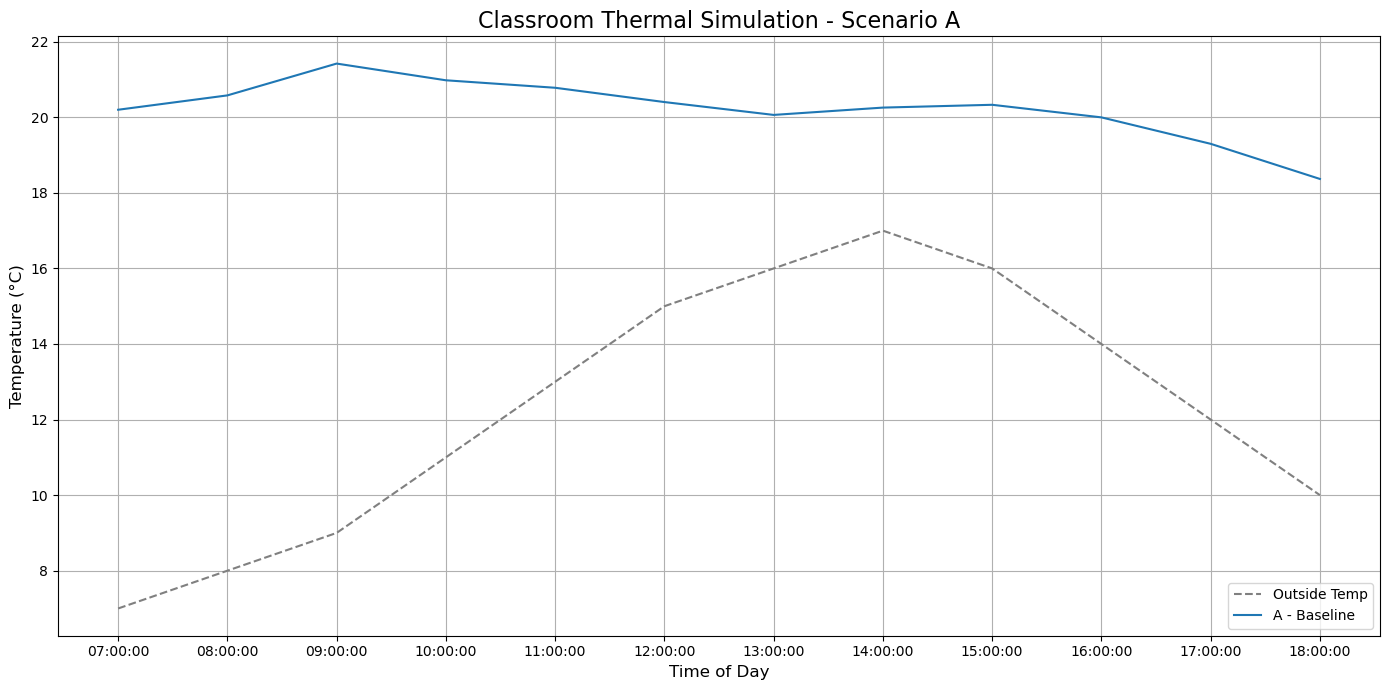

In [5]:
temp_A = run_simulation(df)

time_labels = df['time'].astype(str).tolist()

plt.figure(figsize=(14, 7))
plt.plot(time_labels, df['outside_temp'], label='Outside Temp', linestyle='--', color='gray')
plt.plot(time_labels, temp_A, label='A - Baseline')

plt.title('Classroom Thermal Simulation - Scenario A', fontsize=16)
plt.xlabel('Time of Day', fontsize=12)
plt.ylabel('Temperature (°C)', fontsize=12)
plt.legend(loc='lower right') 
plt.grid(True)
plt.tight_layout()
plt.show()

### What if scenario: B
No heating

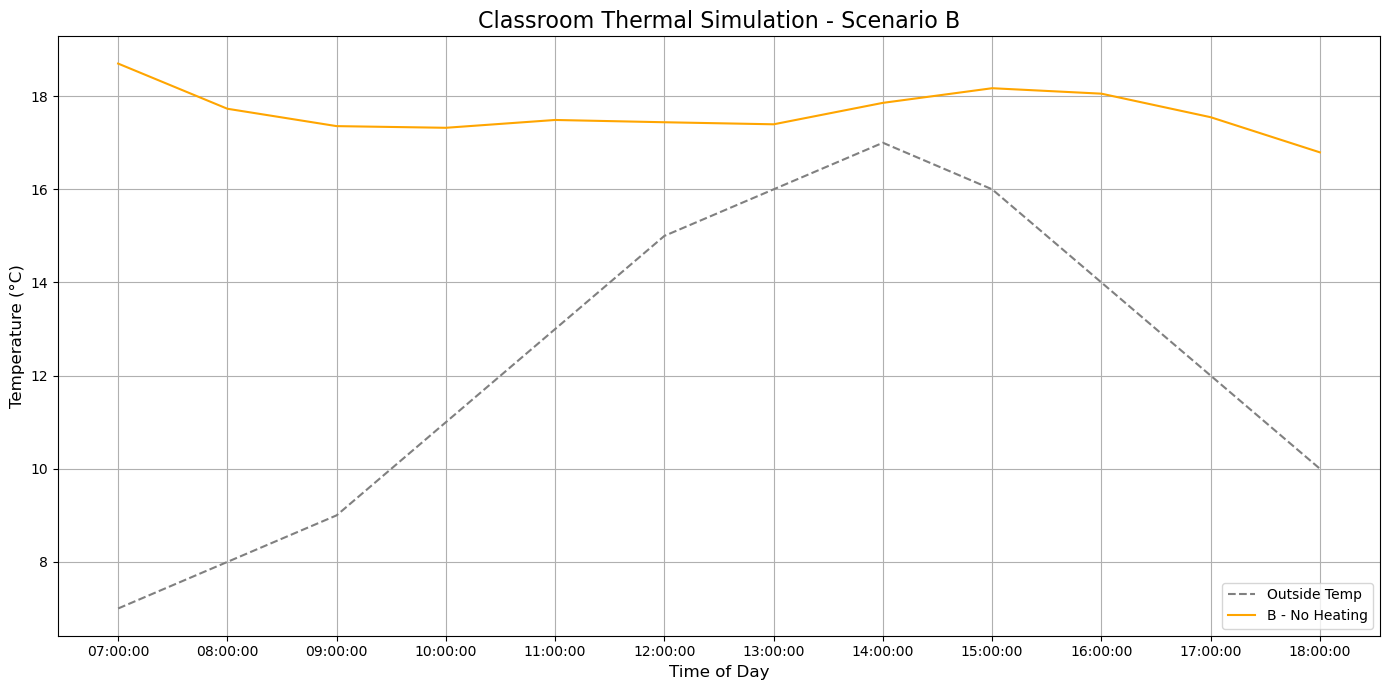

In [8]:
temp_B = run_simulation(df, hvac_modifier=0.0)

time_labels = df['time'].astype(str).tolist()

plt.figure(figsize=(14, 7))
plt.plot(time_labels, df['outside_temp'], label='Outside Temp', linestyle='--', color='gray')
plt.plot(time_labels, temp_B, label='B - No Heating', color='orange')

plt.title('Classroom Thermal Simulation - Scenario B', fontsize=16)
plt.xlabel('Time of Day', fontsize=12)
plt.ylabel('Temperature (°C)', fontsize=12)
plt.legend(loc='lower right') 
plt.grid(True)
plt.tight_layout()
plt.show()

### What is scenario: C
Full Clasroom

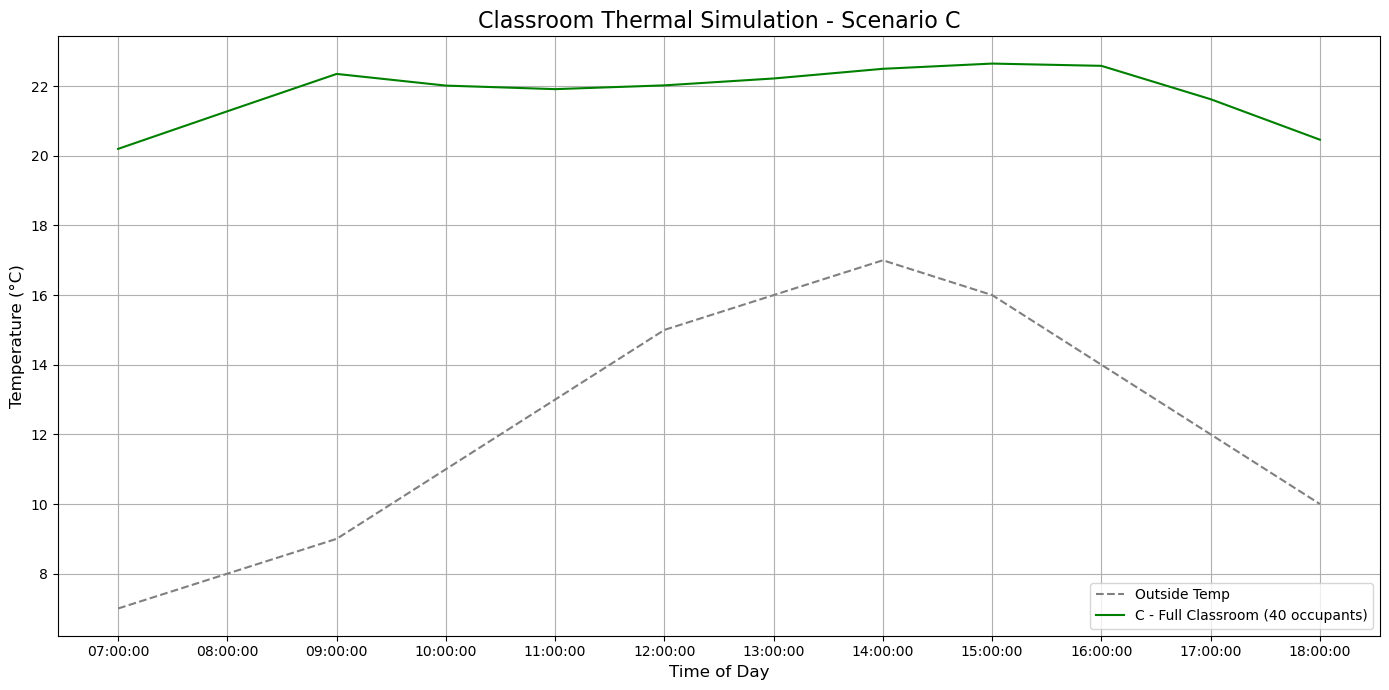

In [10]:
temp_C = run_simulation(df, occupant_mode='full')

time_labels = df['time'].astype(str).tolist()

plt.figure(figsize=(14, 7))
plt.plot(time_labels, df['outside_temp'], label='Outside Temp', linestyle='--', color='gray')
plt.plot(time_labels, temp_C, label='C - Full Classroom (40 occupants)', color='green')

plt.title('Classroom Thermal Simulation - Scenario C', fontsize=16)
plt.xlabel('Time of Day', fontsize=12)
plt.ylabel('Temperature (°C)', fontsize=12)
plt.legend(loc='lower right') 
plt.grid(True)
plt.tight_layout()
plt.show()

### What if scenario: D
Cold day (-5 °C)

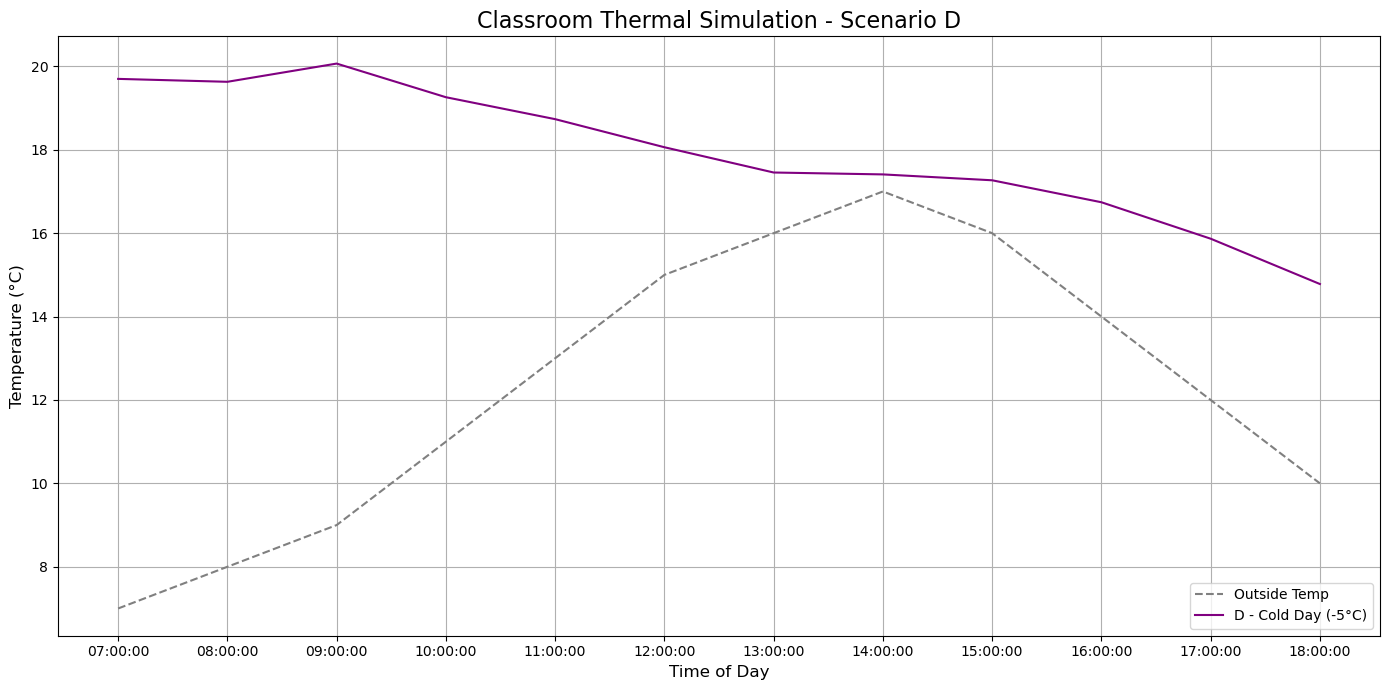

In [11]:
temp_D = run_simulation(df, t_out_offset=-5.0)

time_labels = df['time'].astype(str).tolist()

plt.figure(figsize=(14, 7))
plt.plot(time_labels, df['outside_temp'], label='Outside Temp', linestyle='--', color='gray')
plt.plot(time_labels, temp_D, label='D - Cold Day (-5°C)', color='purple')

plt.title('Classroom Thermal Simulation - Scenario D', fontsize=16)
plt.xlabel('Time of Day', fontsize=12)
plt.ylabel('Temperature (°C)', fontsize=12)
plt.legend(loc='lower right') 
plt.grid(True)
plt.tight_layout()
plt.show()

### What if scenario: E
Extreme Cold (-10 °C) - Krisztian's scenario

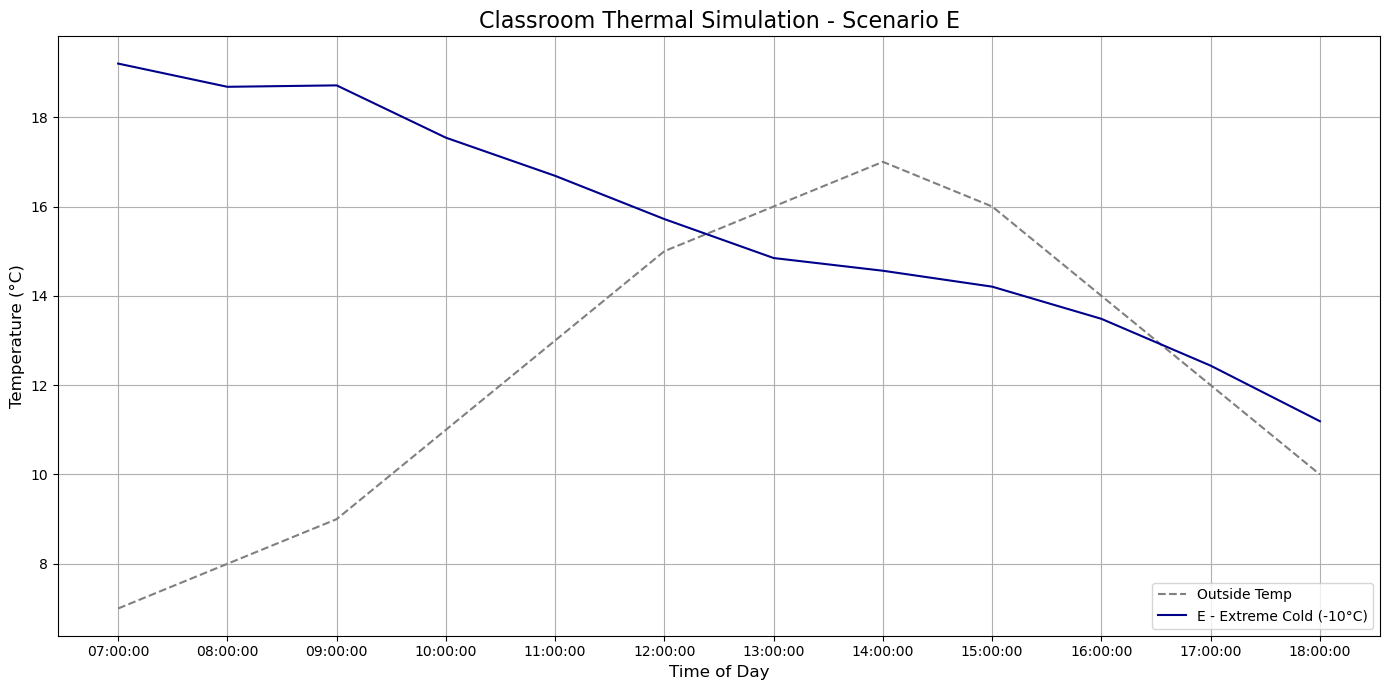

In [15]:
temp_E = run_simulation(df, t_out_offset=-10.0)

time_labels = df['time'].astype(str).tolist()

plt.figure(figsize=(14, 7))
plt.plot(time_labels, df['outside_temp'], label='Outside Temp', linestyle='--', color='gray')
plt.plot(time_labels, temp_E, label='E - Extreme Cold (-10°C)', color='darkblue')

plt.title('Classroom Thermal Simulation - Scenario E', fontsize=16)
plt.xlabel('Time of Day', fontsize=12)
plt.ylabel('Temperature (°C)', fontsize=12)
plt.legend(loc='lower right') 
plt.grid(True)
plt.tight_layout()
plt.show()